In [ ]:
#1.Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import Food101
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
#2. Super-Category Mapping
SUPER_CATEGORIES = {
    0: ("Pies & Pastries",       ["apple_pie", "baklava", "cannoli", "churros"]),
    1: ("Cakes & Desserts",      ["cheesecake", "chocolate_cake", "cup_cakes", "waffles", "donuts"]),
    2: ("Meat & Seafood",        ["steak", "baby_back_ribs", "chicken_wings", "shrimp_and_grits", "sashimi", "oysters"]),
    3: ("Fast Food & Snacks",    ["pizza", "hamburger", "hot_dog", "nachos", "french_fries"]),
    4: ("Noodles, Rice & Bread", ["ramen", "pad_thai", "fried_rice", "bread_pudding", "hummus"]),
    5: ("Soups & Stews",         ["pho", "clam_chowder", "french_onion_soup", "lobster_bisque"]),
    6: ("Salads & Vegetables",   ["caesar_salad", "edamame", "guacamole", "caprese_salad"]),
    7: ("Breakfast & Eggs",      ["eggs_benedict", "pancakes", "french_toast", "omelette"]),
}

SUPER_CATEGORY_NAMES = [SUPER_CATEGORIES[i][0] for i in range(8)]
NUM_CLASSES = 8

CLASS_TO_SUPER = {}
for super_idx, (_, food_classes) in SUPER_CATEGORIES.items():
    for cls in food_classes:
        CLASS_TO_SUPER[cls] = super_idx


In [ ]:
# 3. Custom Dataset Wrapper
class Food101SuperCategory(torch.utils.data.Dataset):
    
    def __init__(self, root, split, transform):
        self.base = Food101(root=root, split=split, transform=transform, download=True)
        food101_classes = self.base.classes
        self.label_map = {
            i: CLASS_TO_SUPER.get(name, -1)
            for i, name in enumerate(food101_classes)
        }
        self.valid_indices = [
            i for i, lbl in enumerate(self.base._labels)
            if self.label_map[lbl] != -1
        ]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        image, orig_label = self.base[self.valid_indices[idx]]
        return image, self.label_map[orig_label]



In [ ]:
#  4. Hyperparameters 
IMAGE_SIZE    = 224     # ResNet-50 standard input size
BATCH_SIZE    = 32
LEARNING_RATE = 0.001  
NUM_EPOCHS    = 20


In [ ]:
# 5. Transforms 
# Use ImageNet normalization — ResNet-50 was trained with these exact values
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])



In [ ]:
# 6. Load Dataset 
print("Loading Food-101 with 8 super-categories...")

train_dataset = Food101SuperCategory(root="./data", split="train", transform=train_transform)
test_dataset  = Food101SuperCategory(root="./data", split="test",  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")



Loading Food-101 with 8 super-categories...
Training samples : 27750
Test samples     : 9250


In [ ]:
# 7. Load Pre-Trained ResNet-50

print("\nLoading ResNet-50 with ImageNet pre-trained weights...")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

# in_features = 2048 for ResNet-50
in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(p=0.4),
    nn.Linear(512, NUM_CLASSES),
)

model = model.to(device)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"ResNet-50 loaded ")
print(f"Total parameters     : {total_params:,}")
print(f"Frozen parameters    : {frozen_params:,}  (backbone — never updated)")
print(f"Trainable parameters : {trainable_params:,}  (head only)")




Loading ResNet-50 with ImageNet pre-trained weights...
ResNet-50 loaded 
Total parameters     : 24,561,224
Frozen parameters    : 23,508,032  (backbone — never updated)
Trainable parameters : 1,053,192  (head only)


In [ ]:

# 8. Loss & Optimizer 
criterion = nn.CrossEntropyLoss()

# Only pass head parameters to the optimizer — backbone params are frozen
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)



In [ ]:
# 9. Train 
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += outputs.argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
    return running_loss / total, 100.0 * correct / total



In [ ]:
# 10. Training Loop
train_losses, train_accs = [], []
test_losses,  test_accs  = [], []

print("\n" + "="*65)
print("  Pre-Trained ResNet-50 ")
print("="*65)

for epoch in range(1, NUM_EPOCHS + 1):
    current_lr = optimizer.param_groups[0]["lr"]

    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    te_loss, te_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(tr_loss);  train_accs.append(tr_acc)
    test_losses.append(te_loss);   test_accs.append(te_acc)

    scheduler.step()

    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS}]  LR: {current_lr:.5f}  |  "
          f"Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.2f}%  |  "
          f"Test Loss: {te_loss:.4f}  Test Acc: {te_acc:.2f}%")

print("="*65)
print("Training complete.")




  Pre-Trained ResNet-50 
Epoch [01/20]  LR: 0.00100  |  Train Loss: 1.2808  Train Acc: 54.71%  |  Test Loss: 0.9122  Test Acc: 68.49%
Epoch [02/20]  LR: 0.00100  |  Train Loss: 1.1732  Train Acc: 58.95%  |  Test Loss: 0.8146  Test Acc: 71.99%
Epoch [03/20]  LR: 0.00100  |  Train Loss: 1.1330  Train Acc: 59.97%  |  Test Loss: 0.8000  Test Acc: 72.28%
Epoch [04/20]  LR: 0.00100  |  Train Loss: 1.0990  Train Acc: 61.16%  |  Test Loss: 0.7650  Test Acc: 73.52%
Epoch [05/20]  LR: 0.00100  |  Train Loss: 1.0722  Train Acc: 62.55%  |  Test Loss: 0.7553  Test Acc: 74.28%
Epoch [06/20]  LR: 0.00050  |  Train Loss: 0.9974  Train Acc: 65.22%  |  Test Loss: 0.6837  Test Acc: 76.77%
Epoch [07/20]  LR: 0.00050  |  Train Loss: 0.9770  Train Acc: 66.07%  |  Test Loss: 0.6806  Test Acc: 76.40%
Epoch [08/20]  LR: 0.00050  |  Train Loss: 0.9633  Train Acc: 66.61%  |  Test Loss: 0.6522  Test Acc: 77.92%
Epoch [09/20]  LR: 0.00050  |  Train Loss: 0.9462  Train Acc: 66.87%  |  Test Loss: 0.6479  Test Acc: 

In [ ]:
# 11. Save Model
torch.save(model.state_dict(), "pretrained_resnet50.pth")
print("Model saved → pretrained_resnet50.pth")


Model saved → pretrained_resnet50.pth


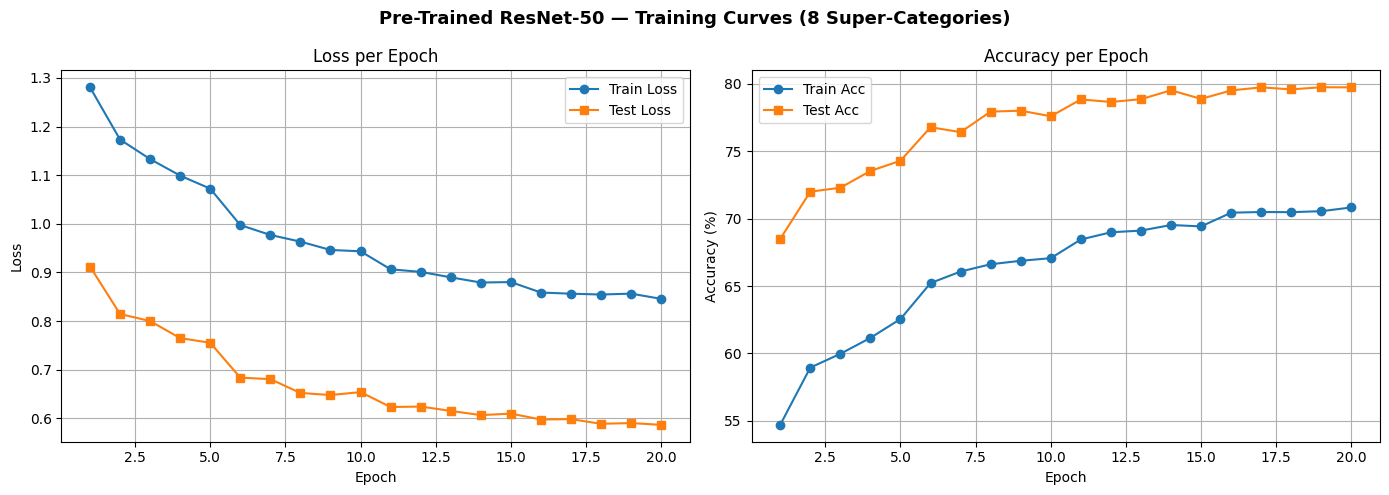

Saved → pretrained_training_curves.png


In [ ]:
# 12. Training Curves
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pre-Trained ResNet-50 — Training Curves (8 Super-Categories)",
             fontsize=13, fontweight="bold")

axes[0].plot(epochs_range, train_losses, label="Train Loss", marker="o")
axes[0].plot(epochs_range, test_losses,  label="Test Loss",  marker="s")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, train_accs, label="Train Acc", marker="o")
axes[1].plot(epochs_range, test_accs,  label="Test Acc",  marker="s")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig("pretrained_training_curves.png", dpi=150)
plt.show()
print("Saved → pretrained_training_curves.png")



In [ ]:
# 13. Detailed Evaluation 
print("\nRunning full evaluation on test set...")
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=SUPER_CATEGORY_NAMES,
                             zero_division=0))

final_acc = 100.0 * (all_preds == all_labels).sum() / len(all_labels)
print(f"Overall Test Accuracy: {final_acc:.2f}%")




Running full evaluation on test set...

Classification Report:
                       precision    recall  f1-score   support

      Pies & Pastries       0.73      0.71      0.72      1000
     Cakes & Desserts       0.82      0.82      0.82      1250
       Meat & Seafood       0.80      0.84      0.82      1500
   Fast Food & Snacks       0.84      0.84      0.84      1250
Noodles, Rice & Bread       0.74      0.70      0.72      1250
        Soups & Stews       0.85      0.90      0.87      1000
  Salads & Vegetables       0.88      0.82      0.85      1000
     Breakfast & Eggs       0.71      0.73      0.72      1000

             accuracy                           0.80      9250
            macro avg       0.80      0.80      0.80      9250
         weighted avg       0.80      0.80      0.80      9250

Overall Test Accuracy: 79.72%


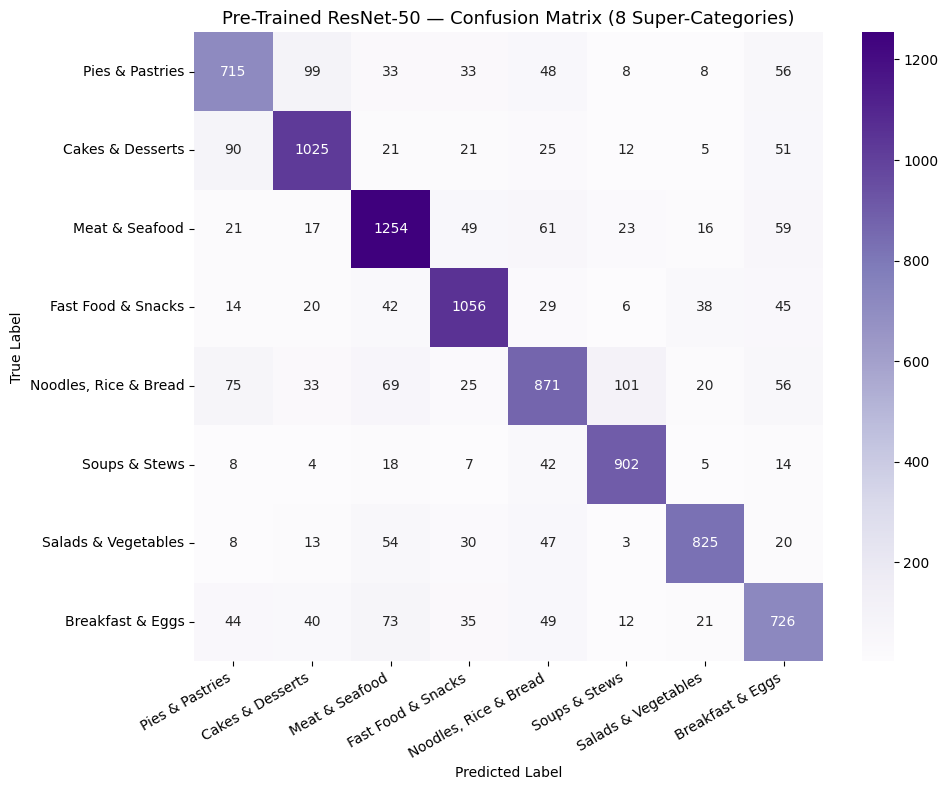

Saved → pretrained_confusion_matrix.png


In [ ]:
# 14. Confusion Matrix 
cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=SUPER_CATEGORY_NAMES,
            yticklabels=SUPER_CATEGORY_NAMES)
plt.title("Pre-Trained ResNet-50 — Confusion Matrix (8 Super-Categories)", fontsize=13)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("pretrained_confusion_matrix.png", dpi=150)
plt.show()
print("Saved → pretrained_confusion_matrix.png")




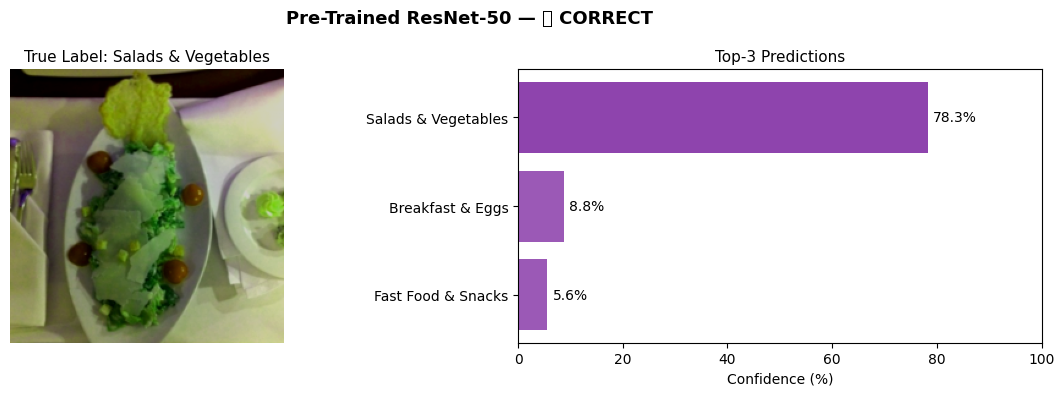

In [ ]:
# 15. Test on a Random Training Image
import random

model.eval()
rand_idx = random.randint(0, len(train_dataset) - 1)
image_tensor, true_label = train_dataset[rand_idx]

mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])
img_display = image_tensor * std[:, None, None] + mean[:, None, None]
img_display = img_display.permute(1, 2, 0).clamp(0, 1).numpy()

with torch.no_grad():
    outputs = model(image_tensor.unsqueeze(0).to(device))
    probs   = torch.softmax(outputs, dim=1)[0]
    top3    = probs.topk(3)

top3_names  = [SUPER_CATEGORY_NAMES[i] for i in top3.indices.cpu().numpy()]
top3_scores = top3.values.cpu().numpy() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img_display)
axes[0].axis("off")
axes[0].set_title(f"True Label: {SUPER_CATEGORY_NAMES[true_label]}", fontsize=11)

colors = ["#8e44ad" if top3.indices[0].item() == true_label else "#e74c3c"] + ["#9b59b6"] * 2
axes[1].barh(top3_names[::-1], top3_scores[::-1], color=colors[::-1])
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Confidence (%)")
axes[1].set_title("Top-3 Predictions", fontsize=11)
for j, (name, score) in enumerate(zip(top3_names[::-1], top3_scores[::-1])):
    axes[1].text(score + 1, j, f"{score:.1f}%", va="center", fontsize=10)

result = "CORRECT" if top3.indices[0].item() == true_label else f"WRONG (true: {SUPER_CATEGORY_NAMES[true_label]})"
plt.suptitle(f"Pre-Trained ResNet-50 — {result}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()




Upload a food image to classify:


Saving soup.jfif to soup.jfif


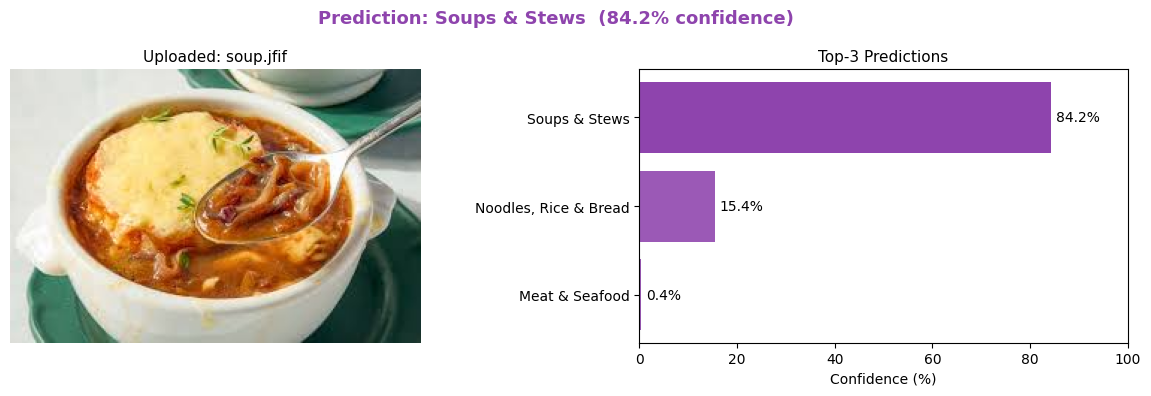


Top-3 Predictions for 'soup.jfif':
  1. Soups & Stews             84.19%
  2. Noodles, Rice & Bread     15.41%
  3. Meat & Seafood            0.38%


In [ ]:
# 17. Interactive Single-Image Prediction (Colab)
from google.colab import files
from PIL import Image
import io

print("\nUpload a food image to classify:")
uploaded = files.upload()

for filename, file_bytes in uploaded.items():
    img = Image.open(io.BytesIO(file_bytes)).convert("RGB")

    preprocess = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    input_tensor = preprocess(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probs   = torch.softmax(outputs, dim=1)[0]
        top3    = probs.topk(3)

    top3_names  = [SUPER_CATEGORY_NAMES[i] for i in top3.indices.cpu().numpy()]
    top3_scores = top3.values.cpu().numpy() * 100

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title(f"Uploaded: {filename}", fontsize=11)

    colors = ["#8e44ad" if i == 0 else "#9b59b6" for i in range(3)]
    axes[1].barh(top3_names[::-1], top3_scores[::-1], color=colors[::-1])
    axes[1].set_xlim(0, 100)
    axes[1].set_xlabel("Confidence (%)")
    axes[1].set_title("Top-3 Predictions", fontsize=11)
    for j, (name, score) in enumerate(zip(top3_names[::-1], top3_scores[::-1])):
        axes[1].text(score + 1, j, f"{score:.1f}%", va="center", fontsize=10)

    plt.suptitle(
        f"Prediction: {top3_names[0]}  ({top3_scores[0]:.1f}% confidence)",
        fontsize=13, fontweight="bold", color="#8e44ad"
    )
    plt.tight_layout()
    plt.show()

    print(f"\nTop-3 Predictions for '{filename}':")
    for i, (name, score) in enumerate(zip(top3_names, top3_scores), 1):
        print(f"  {i}. {name:<25} {score:.2f}%")